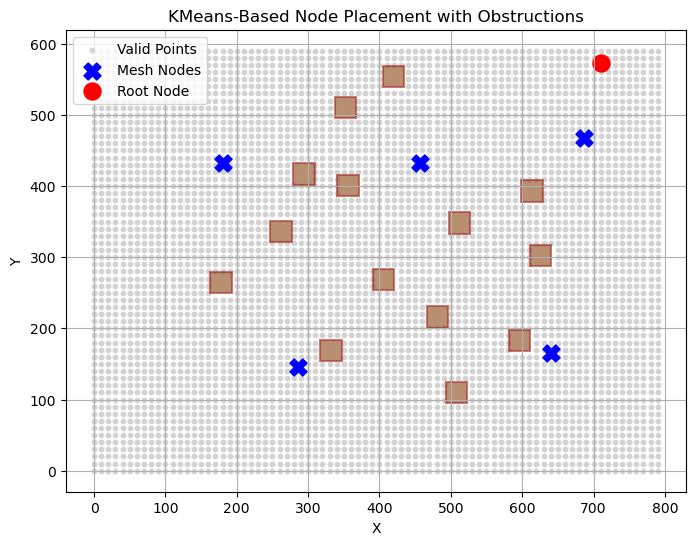

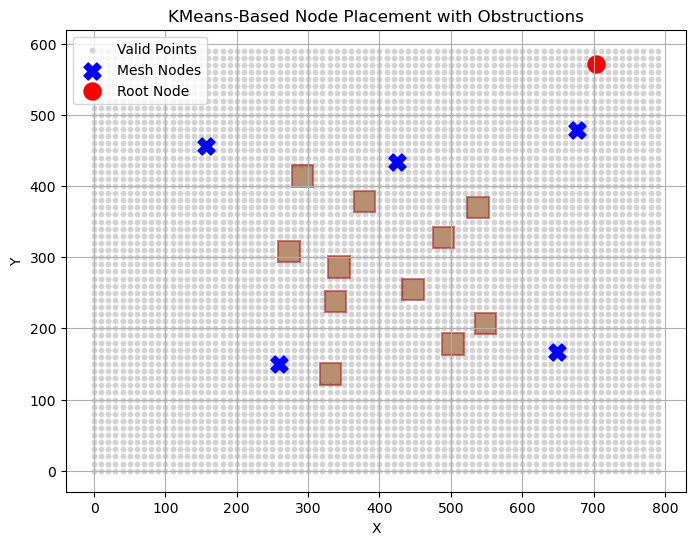

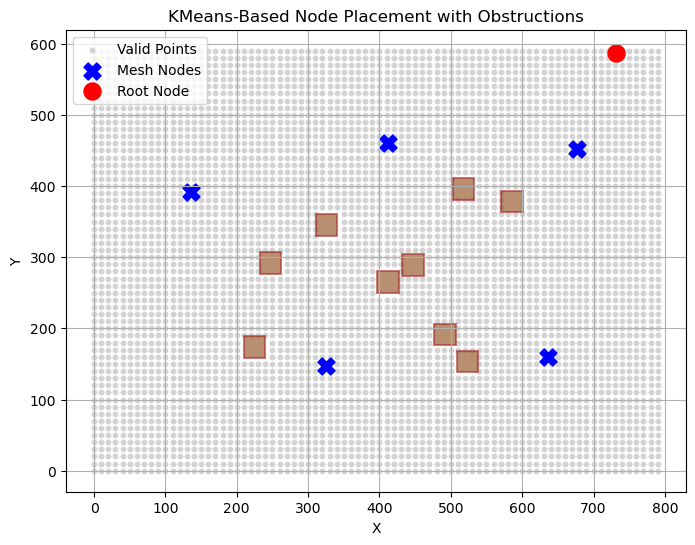

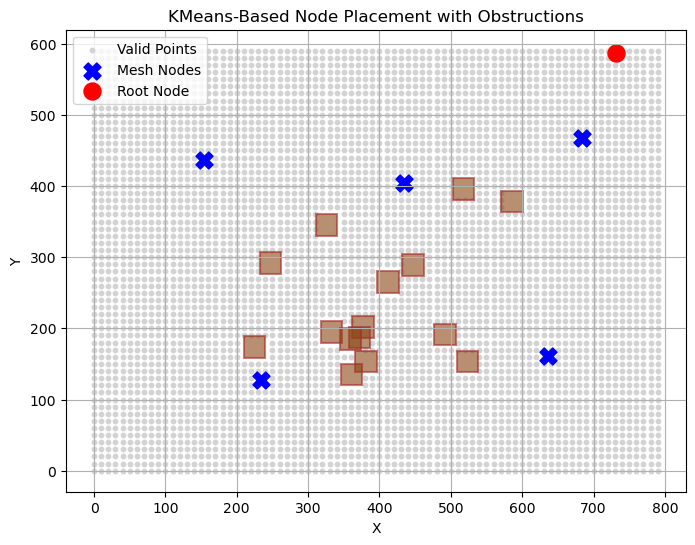

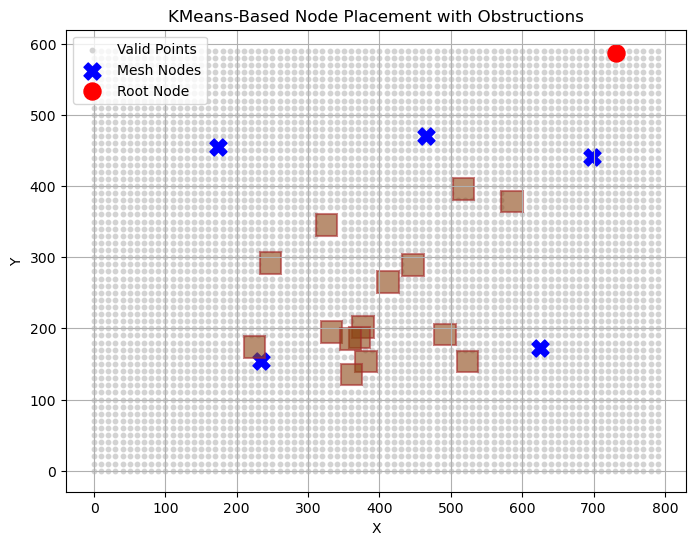

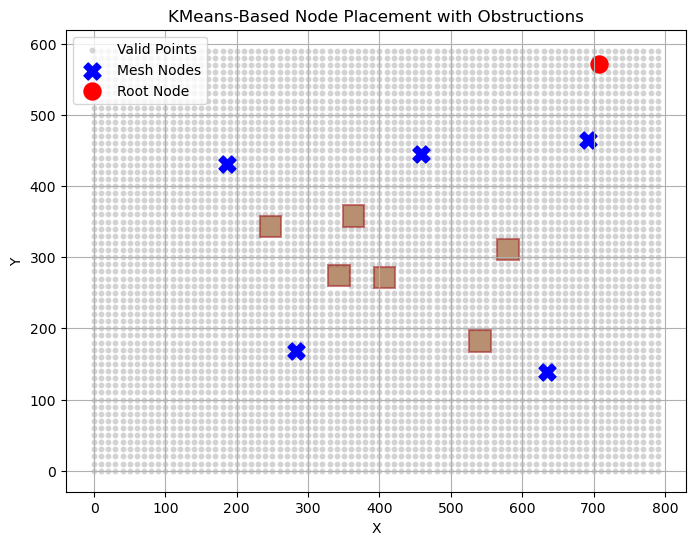

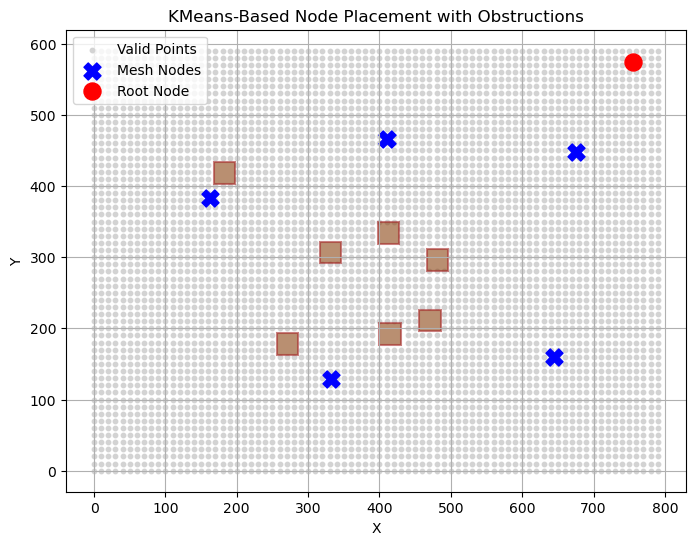

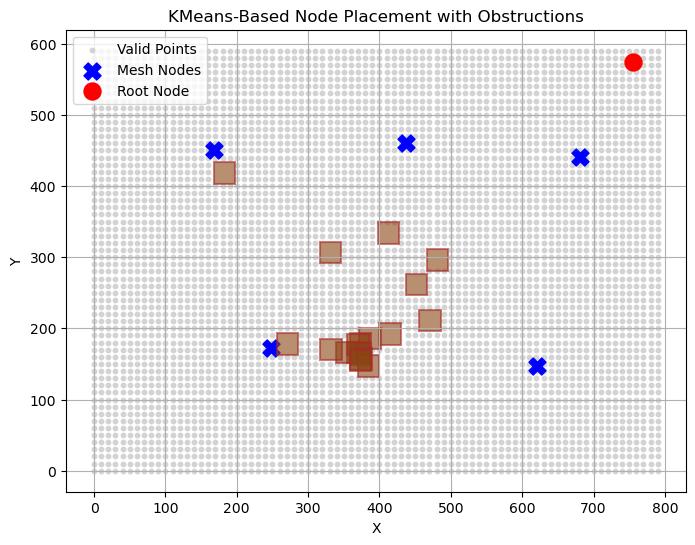

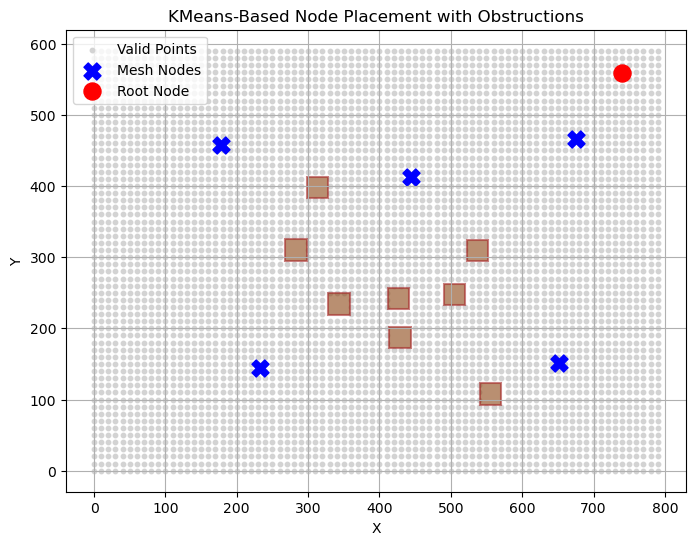

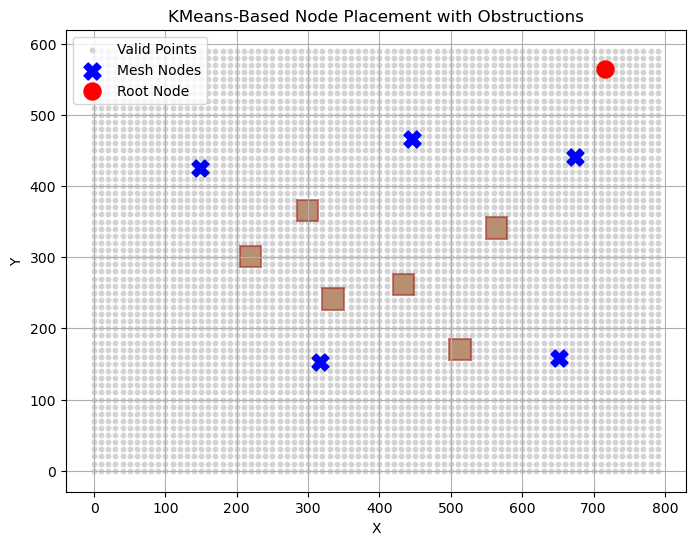

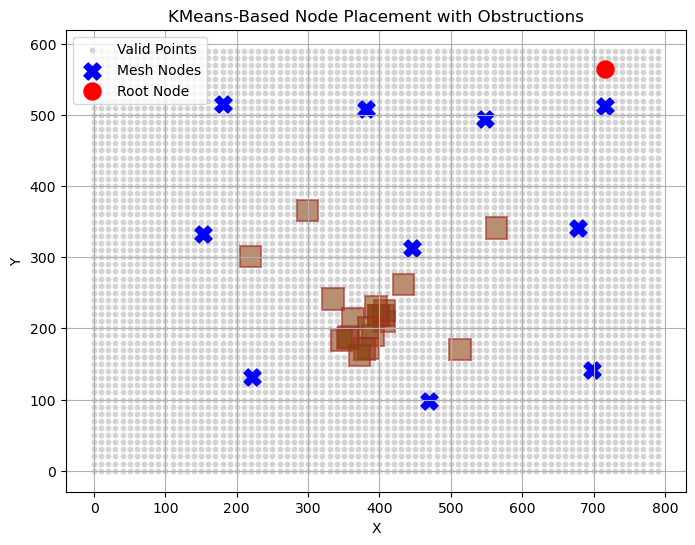

In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
from tkinter import messagebox
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class NodePlacementSimulator:
    def __init__(self, root):
        self.root = root
        self.root.title("dMRV Mesh Network Node Placement Simulator")

        self.canvas = tk.Canvas(root, width=800, height=600, bg="white")
        self.canvas.pack()

        self.upload_button = tk.Button(root, text="Upload Map", command=self.upload_map)
        self.upload_button.pack(side=tk.LEFT)

        self.mark_obstruction_button = tk.Button(root, text="Mark Obstruction", command=self.mark_obstruction)
        self.mark_obstruction_button.pack(side=tk.LEFT)

        self.place_root_button = tk.Button(root, text="Place Root Node", command=self.place_root_node)
        self.place_root_button.pack(side=tk.LEFT)

        self.node_slider = tk.Scale(root, from_=1, to=20, orient=tk.HORIZONTAL, label="Number of Nodes")
        self.node_slider.set(5)
        self.node_slider.pack(side=tk.LEFT)

        self.run_button = tk.Button(root, text="Run KMeans Placement", command=self.run_simulation)
        self.run_button.pack(side=tk.LEFT)

        self.reset_button = tk.Button(root, text="Reset", command=self.reset_simulation)
        self.reset_button.pack(side=tk.LEFT)

        self.canvas.bind("<Button-1>", self.canvas_click)

        self.image = None
        self.tk_image = None
        self.obstructions = []
        self.root_coords = None
        self.mode = None
        self.placed_node_tags = []
        
        self.status_label = tk.Label(root, text="Mode: None", bd=1, relief=tk.SUNKEN, anchor=tk.W)
        self.status_label.pack(side=tk.BOTTOM, fill=tk.X)
        
        self.select_node_button = tk.Button(root, text="Select Node", command=self.select_node_mode)
        self.select_node_button.pack(side=tk.LEFT)

        self.show_path_button = tk.Button(root, text="Show Path to Root", command=self.show_path)
        self.show_path_button.pack(side=tk.LEFT)



        # Add to your existing instance variables
        self.node_positions = []  # Store node positions after placement
        self.selected_node = None  # Track the selected node
        self.path_lines = []  # Store line objects for the path
        
            # Hop limit slider
        self.hop_slider = tk.Scale(root, from_=1, to=10, orient=tk.HORIZONTAL, label="Max Hops")
        self.hop_slider.set(3)
        self.hop_slider.pack(side=tk.LEFT)

        # Remove node button
        self.remove_node_button = tk.Button(root, text="Remove Node", command=self.remove_node_mode)
        self.remove_node_button.pack(side=tk.LEFT)

    def upload_map(self):
        file_path = filedialog.askopenfilename()
        if not file_path:
            return
        self.image = Image.open(file_path).resize((800, 600))
        self.tk_image = ImageTk.PhotoImage(self.image)
        self.canvas.create_image(0, 0, anchor=tk.NW, image=self.tk_image)

    def mark_obstruction(self):
        self.mode = "obstruction"
        self.status_label.config(text="Mode: Placing Obstructions", fg="green")
        # Reset other button highlights if needed
        self.mark_obstruction_button.config(relief=tk.SUNKEN)
        self.place_root_button.config(relief=tk.RAISED)
        self.remove_node_button.config(relief=tk.RAISED)

    def place_root_node(self):
        self.mode = "root"
        self.status_label.config(text="Mode: Placing Root Node", fg="red")
        # Reset other button highlights if needed
        self.place_root_button.config(relief=tk.SUNKEN)
        self.mark_obstruction_button.config(relief=tk.RAISED)
        self.remove_node_button.config(relief=tk.RAISED)
        
    def select_node_mode(self):
        self.mode = "select_node"
        self.status_label.config(text="Mode: Selecting Node", fg="blue")
        # Highlight active button
        self.select_node_button.config(relief=tk.SUNKEN)
        self.mark_obstruction_button.config(relief=tk.RAISED)
        self.place_root_button.config(relief=tk.RAISED)
        self.remove_node_button.config(relief=tk.RAISED)
        
    def remove_node_mode(self):
        self.mode = "remove_node"
        self.status_label.config(text="Mode: Removing Node", fg="purple")
        # Highlight active button
        self.remove_node_button.config(relief=tk.SUNKEN)
        self.select_node_button.config(relief=tk.RAISED)
        self.mark_obstruction_button.config(relief=tk.RAISED)
        self.place_root_button.config(relief=tk.RAISED)

    def canvas_click(self, event):
        x, y = event.x, event.y

        if self.mode == "obstruction":
            w, h = 30, 30  # size of rectangular obstruction
            rect = self.canvas.create_rectangle(x, y, x + w, y + h, fill="green", outline="black", tags="obstruction")
            self.obstructions.append((x, y, w, h))
        elif self.mode == "root":
            if self.root_coords:
                self.canvas.delete("root")
            self.root_coords = (x, y)
            self.canvas.create_oval(x-5, y-5, x+5, y+5, fill="red", tags="root")
        elif self.mode == "select_node":
            # Find the closest node to the click
            if not self.node_positions:
                messagebox.showinfo("Error", "No nodes placed yet. Run simulation first.")
                return

            closest_node = min(self.node_positions, key=lambda pos: (pos[0]-x)**2 + (pos[1]-y)**2)
            closest_idx = self.node_positions.index(closest_node)

            # Clear previous selection
            if self.selected_node is not None:
                self.canvas.delete(f"selected_node_{self.selected_node}")

            # Mark the selected node with an X
            nx, ny = closest_node
            self.canvas.create_text(nx, ny, text="X", fill="red", font=("Arial", 12, "bold"), 
                                  tags=f"selected_node_{closest_idx}")
            self.selected_node = closest_idx

            # Clear previous path
            self.clear_path()
        elif self.mode == "remove_node":
            if not self.node_positions:
                messagebox.showinfo("Error", "No nodes placed yet. Run simulation first.")
                return

            # Find the closest node to click
            closest_node = min(self.node_positions, key=lambda pos: (pos[0]-x)**2 + (pos[1]-y)**2)
            closest_idx = self.node_positions.index(closest_node)

            # Get the node position
            nx, ny = closest_node

            # Remove the actual visual element from the canvas
            items_at_position = self.canvas.find_overlapping(nx-5, ny-5, nx+5, ny+5)

            for item in items_at_position:
                # Only delete the node, not other elements like the background
                tags = self.canvas.gettags(item)
                if tags and "node" in tags:
                    self.canvas.delete(item)

            # Also delete the selection marker if it exists
            self.canvas.delete(f"selected_node_{closest_idx}")

            # Remove from our data structures
            self.node_positions.pop(closest_idx)
            if closest_idx < len(self.placed_node_tags):
                self.placed_node_tags.pop(closest_idx)

            # Handle the selected node if needed
            if self.selected_node == closest_idx:
                # If we're removing the selected node, clear selection
                self.selected_node = None
                self.clear_path()
            elif self.selected_node is not None and self.selected_node > closest_idx:
                # If we're removing a node before the selected one, update index
                self.canvas.delete(f"selected_node_{self.selected_node}")
                self.selected_node -= 1
                if self.selected_node >= 0 and self.selected_node < len(self.node_positions):
                    new_pos = self.node_positions[self.selected_node]
                    nx, ny = new_pos
                    self.canvas.create_text(nx, ny, text="X", fill="red", font=("Arial", 12, "bold"), 
                                         tags=f"selected_node_{self.selected_node}")
    def run_simulation(self):
        num_nodes = self.node_slider.get()
        if self.root_coords is None:
            messagebox.showinfo("Error", "Please place a root node.")
            return

        # Generate candidate points
        candidate_points = [(x, y) for x in range(0, 800, 10) for y in range(0, 600, 10)]
        valid_points = [p for p in candidate_points if not self.is_in_obstruction(p)]

        if len(valid_points) < num_nodes:
            messagebox.showinfo("Error", "Not enough valid space for node placement.")
            return

        valid_points = np.array(valid_points)

        # Calculate distances to root and assign weights
        distances = np.array([distance(p, self.root_coords) for p in valid_points])
        max_distance = np.max(distances)
        # Avoid division by zero
        if max_distance == 0:
            weights = np.ones_like(distances)
        else:
            weights = 1 - (distances / max_distance)  # Closer points have higher weights

        # Normalize weights to sum to 1
        weights /= np.sum(weights)

        # Sample points based on weights
        sample_size = min(len(valid_points), num_nodes * 100)
        sampled_indices = np.random.choice(len(valid_points), size=sample_size, replace=False, p=weights)
        sampled_points = valid_points[sampled_indices]

        # Perform KMeans clustering
        kmeans = KMeans(n_clusters=num_nodes, n_init=10, max_iter=300, random_state=42)
        kmeans.fit(sampled_points)
        centroids = kmeans.cluster_centers_

        # Clear previous nodes
        for tag in self.placed_node_tags:
            self.canvas.delete(tag)
        self.placed_node_tags.clear()
        self.node_positions.clear()

        # Draw new nodes
        for (x, y) in centroids:
            tag = self.canvas.create_oval(x-5, y-5, x+5, y+5, fill="blue", outline="", tags="node")
            self.placed_node_tags.append(tag)
            self.node_positions.append((x, y))

        self.plot_with_obstructions(valid_points, centroids)
        
            # Performance improvement: Adjust grid spacing based on area size
        grid_step = 20  # Increased from 10 to reduce computation
        candidate_points = [(x, y) for x in range(0, 800, grid_step) for y in range(0, 600, grid_step)]

        # Optional: Add more points near obstructions and root node for better precision
        extra_points = []
        if self.root_coords:
            rx, ry = self.root_coords
            for dx in range(-30, 31, 10):
                for dy in range(-30, 31, 10):
                    nx, ny = rx + dx, ry + dy
                    if 0 <= nx < 800 and 0 <= ny < 600:
                        extra_points.append((nx, ny))

        candidate_points.extend(extra_points)
        valid_points = [p for p in candidate_points if not self.is_in_obstruction(p)]

    def is_in_obstruction(self, point):
        x, y = point
        for ox, oy, ow, oh in self.obstructions:
            if ox <= x <= ox + ow and oy <= y <= oy + oh:
                return True
        return False

    def plot_with_obstructions(self, valid_points, centroids):
        plt.figure(figsize=(8, 6))
        plt.scatter(valid_points[:, 0], valid_points[:, 1], s=10, color='lightgray', label="Valid Points")
        plt.scatter(centroids[:, 0], centroids[:, 1], s=150, c='blue', marker='X', label='Mesh Nodes')

        if self.root_coords:
            plt.scatter(self.root_coords[0], self.root_coords[1], s=150, c='red', marker='o', label='Root Node')

        for (ox, oy, ow, oh) in self.obstructions:
            rect = patches.Rectangle((ox, oy), ow, oh, linewidth=1.5, edgecolor='brown', facecolor='saddlebrown', alpha=0.6)
            plt.gca().add_patch(rect)

        plt.title("KMeans-Based Node Placement with Obstructions")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    def find_path(self, start_pos, end_pos, max_hops):
        """A* pathfinding algorithm for better path selection"""
        import heapq

        def heuristic(pos):
            return distance(pos, end_pos)

        # Start with our selected node
        open_set = [(heuristic(start_pos), 0, start_pos, [start_pos])]
        closed_set = set()

        while open_set:
            _, cost, current, path = heapq.heappop(open_set)

            # Check if we're close enough to the end or reached hop limit
            if distance(current, end_pos) < 50 or len(path) >= max_hops:
                return path + [end_pos] if distance(current, end_pos) >= 50 else path

            current_tuple = (current[0], current[1])
            if current_tuple in closed_set:
                continue

            closed_set.add(current_tuple)

            # Consider all nodes plus the root as next steps
            candidates = self.node_positions + [self.root_coords]

            for next_pos in candidates:
                if (next_pos[0], next_pos[1]) in closed_set or self.is_path_obstructed(current, next_pos):
                    continue

                new_cost = cost + distance(current, next_pos)
                heapq.heappush(open_set, (new_cost + heuristic(next_pos), new_cost, next_pos, path + [next_pos]))

        return [start_pos, end_pos]  # Fallback direct path
    
    def is_path_obstructed(self, start, end):
        """Check if a direct path between two points passes through an obstruction"""
        steps = max(int(distance(start, end) / 5), 1)
        for i in range(steps + 1):
            t = i / steps
            x = start[0] * (1 - t) + end[0] * t
            y = start[1] * (1 - t) + end[1] * t
            if self.is_in_obstruction((x, y)):
                return True
        return False

        
    def show_path(self):
        if self.selected_node is None:
            messagebox.showinfo("Error", "No node selected. Please select a node first.")
            return

        if self.root_coords is None:
            messagebox.showinfo("Error", "No root node placed. Please place a root node.")
            return

        # Clear previous path
        self.clear_path()

        # Get max hops from slider
        max_hops = self.hop_slider.get()

        # Source and destination
        start_pos = self.node_positions[self.selected_node]
        end_pos = self.root_coords

        # Use a breadth-first search approach to find multiple possible paths
        paths = self.find_multiple_paths(start_pos, end_pos, max_hops)

        if not paths:
            messagebox.showinfo("Warning", f"Cannot find path to root within {max_hops} hops.")
            return

        # Select the best path based on obstruction level and hop count
        best_path = self.select_best_path(paths)
        hop_count = len(best_path) - 1  # -1 because path includes start node

        # Draw the path
        for i in range(len(best_path)-1):
            x1, y1 = best_path[i]
            x2, y2 = best_path[i+1]

            # Color based on obstruction level
            obstruction_level = self.calculate_path_obstruction((x1, y1), (x2, y2))
            if obstruction_level == 0:
                color = "green"  # Clear path
            elif obstruction_level < 0.3:
                color = "orange"  # Minimal obstruction
            elif obstruction_level < 0.5:
                color = "red"  # Significant obstruction
            else:
                color = "black"
                messagebox.showinfo("Warning", f"Cannot find path to root within {max_hops} hops.")

            line = self.canvas.create_line(x1, y1, x2, y2, fill=color, width=2, dash=(4,2), tags="path")
            self.path_lines.append(line)

        self.status_label.config(text=f"Path shown: Node {self.selected_node} → Root ({hop_count} hops)")

    def find_multiple_paths(self, start_pos, end_pos, max_hops):
        #Find paths using breadth-first search
        # All possible nodes including the root
        all_nodes = self.node_positions + [self.root_coords]

        # Queue for BFS: (current_pos, path_so_far, visited_nodes)
        queue = [(start_pos, [start_pos], set())]
        all_paths = []

        while queue:
            current_pos, path_so_far, visited = queue.pop(0)

            # Check if we've reached the destination or are close enough
            if current_pos == end_pos or (distance(current_pos, end_pos) < 50 and len(path_so_far) < max_hops):
                if current_pos != end_pos:
                    path_so_far.append(end_pos)
                all_paths.append(path_so_far)
                continue

            # Too many hops
            if len(path_so_far) >= max_hops:
                continue

            # Add neighbors to queue
            for node in all_nodes:
                node_tuple = (node[0], node[1])

                # Skip if we've visited this node or it's our current position
                if node_tuple in visited or node == current_pos:
                    continue

                # Add to queue with updated path and visited set
                new_visited = visited.copy()
                new_visited.add(node_tuple)
                queue.append((node, path_so_far + [node], new_visited))

        return all_paths

    def select_best_path(self, paths):
        # Select the best path based on obstruction level and length
        if not paths:
            return None

        # Calculate score for each path
        path_scores = []
        for path in paths:
            total_obstruction = 0
            for i in range(len(path)-1):
                obstruction = self.calculate_path_obstruction(path[i], path[i+1])
                total_obstruction += obstruction

            # Score considers both path length and obstruction level
            # Lower score is better
            score = (total_obstruction * 3.0) + (len(path) * 0.5)
            path_scores.append((path, score))

        # Return the path with the lowest score
        return min(path_scores, key=lambda x: x[1])[0]

    def calculate_path_obstruction(self, start, end):

        steps = max(int(distance(start, end) / 5), 1)
        obstruction_count = 0

        for i in range(steps + 1):
            t = i / steps
            x = start[0] * (1 - t) + end[0] * t
            y = start[1] * (1 - t) + end[1] * t
            if self.is_in_obstruction((x, y)):
                obstruction_count += 1

        return obstruction_count / (steps + 1)  # Normalize to 0-1 range

    def clear_path(self):
        # Clear all path lines
        for line in self.path_lines:
            self.canvas.delete(line)
        self.path_lines = []

    def reset_simulation(self):
        self.canvas.delete("all")
        self.obstructions.clear()
        self.root_coords = None
        self.mode = None
        self.placed_node_tags.clear()
        self.clear_path()
        self.selected_node = None
        self.node_positions = []
        if self.image:
            self.tk_image = ImageTk.PhotoImage(self.image)
            self.canvas.create_image(0, 0, anchor=tk.NW, image=self.tk_image)
 # Helper function for calculating distance
def distance(point1, point2):
    return ((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)**0.5

# Start GUI
root = tk.Tk()
app = NodePlacementSimulator(root)
root.mainloop()
